# QF 627 Programming and Computational Finance
## Problem Set `5` | `Questions`

> Hi Team! 👋

> The current problem set has two main parts. Questions 1 through 7 are scenario-based, giving you a taste of day-to-day operations as a buy-side Quant in the field. Questions 8 through 12 will help you explore a technical indicator for detecting momentum signals—namely, the Moving Average Convergence Divergence (MACD).

> As always, these questions have been carefully designed to guide your optimal learning. While you read and answer the questions, you’ll be able to feel my affection for you all 🙌

> Enjoy 🤗

### <font color = green> Activation of necessary libraries. </font>

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [4]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 Questions 1 through 7 are based on the following scenario. After reading it, please respond to the associated sub-questions.

> Suppose that you've been appointed as a Quantitative Researcher in the process-driven investing division of a leading hedge fund. As part of your onboarding challenge, you are handed data (`alphas.csv`) for three experimental trading models, codenamed Alphas A, B, and C. These models, each initiated with a capital of 100K, demonstrate nearly identical Sharpe ratios across a span of 1120 trading days. Intrigued by this uniformity yet aware of the Sharpe ratio's shortcomings, you embark on a journey to dissect the Alphas' performance through a multifaceted quantitative lens.

### <font color = blue> 👉 Question 1</font>. Sharpe Ratio Diagnostics:

- Given the daily return series for Alphas A, B, and C:

- Derive the annualized Sharpe ratio for each Alpha, with the industry-standard assumption of 252 trading days per annum. In light of these findings, how might you reconsider the perceived risk-adjusted returns of these models?

1. download data
2. calculate return and cum return
3. calculate sharpe
4. calculate mdd and ldd

### <font color = red> Answer 1 is presented in the cell below: </font>

In [5]:
stock_data = pd.read_csv('alphas.csv',
            index_col=0,
            parse_dates=True)

In [6]:
passive_returns = \
(
    np.log(
        stock_data / 
            stock_data.shift(1)
    )
).fillna(0)
cum_passive_returns = \
(
    passive_returns.cumsum().apply(np.exp).fillna(1)
)

In [7]:
cum_passive_returns

,Alphas A,Alphas B,Alphas C
2019-05-28,1.000000,1.000000,1.000000
2019-05-29,1.005624,1.019917,1.007340
2019-05-30,0.989036,1.045270,1.005689
2019-05-31,1.010464,1.077991,0.991863
2019-06-03,1.016492,1.077507,1.013235
...,...,...,...
2023-09-06,0.871715,0.852129,0.888647
2023-09-07,0.877705,0.851434,0.877824
2023-09-08,0.882041,0.843768,0.873915
2023-09-11,0.884757,0.855312,0.862415


In [8]:
def compute_sharpe_ratio(daily_returns):
    """
    get_sharpe Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std(ddof = 1)

sharpe_ratios = compute_sharpe_ratio(passive_returns)
sharpe_ratios

Alphas A   -0.155761
Alphas B   -0.165297
Alphas C   -0.160180
dtype: float64

In [9]:
def get_drawdowns(cum_returns):
    """
    Calculate the Maximum Drawdown (MDD) and the Longest Drawdown Duration (LDD)
    from a cumulative returns SERIES.

    Parameters:
      cum_returns : pd.SERIES of cumulative returns
    Returns:
      tuple (mdd, ldd)
    Usage: 
      get_drawdowns(df['cum_strategy_returns'])
    """
    def compute_longest_drawdown_period(dd, cum_returns):
      periods =\
      (
          np
          .diff(np.append(dd[dd == 0].index,
                          dd.index[-1: ]
                        )
              )
      )
      return periods.max() / np.timedelta64(1, "D")
    
    daily_drawdown = cum_returns / cum_returns.cummax() - 1
    mdd = daily_drawdown.min()
    ldd = compute_longest_drawdown_period(daily_drawdown, cum_returns) # days
    return mdd, ldd

dd_dct = {}
for ticker in cum_passive_returns.columns:
    dd_dct[ticker] = get_drawdowns(cum_passive_returns[ticker])

In [10]:
dd_dct

{'Alphas A': (-0.544601997329252, 1183.0),
 'Alphas B': (-0.4437168929094025, 1463.0),
 'Alphas C': (-0.47675847269710636, 706.0)}

should consider MDD and LDD too

### <font color = blue> 👉 Question 2</font>. Trajectory of Cumulative Returns:
    
- Visualize and compare the cumulative returns of each Alpha, using both lets-plot and matplotlib libraries.

In [11]:
cum_passive_returns

,Alphas A,Alphas B,Alphas C
2019-05-28,1.000000,1.000000,1.000000
2019-05-29,1.005624,1.019917,1.007340
2019-05-30,0.989036,1.045270,1.005689
2019-05-31,1.010464,1.077991,0.991863
2019-06-03,1.016492,1.077507,1.013235
...,...,...,...
2023-09-06,0.871715,0.852129,0.888647
2023-09-07,0.877705,0.851434,0.877824
2023-09-08,0.882041,0.843768,0.873915
2023-09-11,0.884757,0.855312,0.862415


In [12]:
cum_passive_returns_melt = cum_passive_returns.reset_index()

In [13]:
cum_passive_returns_melt

,index,Alphas A,Alphas B,Alphas C
0,2019-05-28,1.000000,1.000000,1.000000
1,2019-05-29,1.005624,1.019917,1.007340
2,2019-05-30,0.989036,1.045270,1.005689
3,2019-05-31,1.010464,1.077991,0.991863
4,2019-06-03,1.016492,1.077507,1.013235
...,...,...,...,...
1116,2023-09-06,0.871715,0.852129,0.888647
1117,2023-09-07,0.877705,0.851434,0.877824
1118,2023-09-08,0.882041,0.843768,0.873915
1119,2023-09-11,0.884757,0.855312,0.862415


In [14]:
# TODO get_plot lets-plot; basic 
from lets_plot import *
LetsPlot.setup_html()

cum_passive_returns_melt = cum_passive_returns.reset_index()
# cum_passive_returns_melt = cum_passive_returns_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(cum_passive_returns_melt, aes(x='index')) +
    # geom_line(aes(y='cum_passive_returns'), color='grey', size=0.7) +
    geom_line(aes(y='Alphas A'), color='orange', size=0.7) +  
    geom_line(aes(y='Alphas B'), color='blue', size=0.7) +  
    geom_line(aes(y='Alphas C'), color='purple', size=0.7) +  
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    # geom_point(aes(y='sma_50'), data=cum_passive_returns_melt[cum_passive_returns_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
    # geom_point(aes(y='sma_50'), data=cum_passive_returns_melt[cum_passive_returns_melt['trade']<-0.0], color='blue', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


p

Text(0.5, 1.0, 'title')

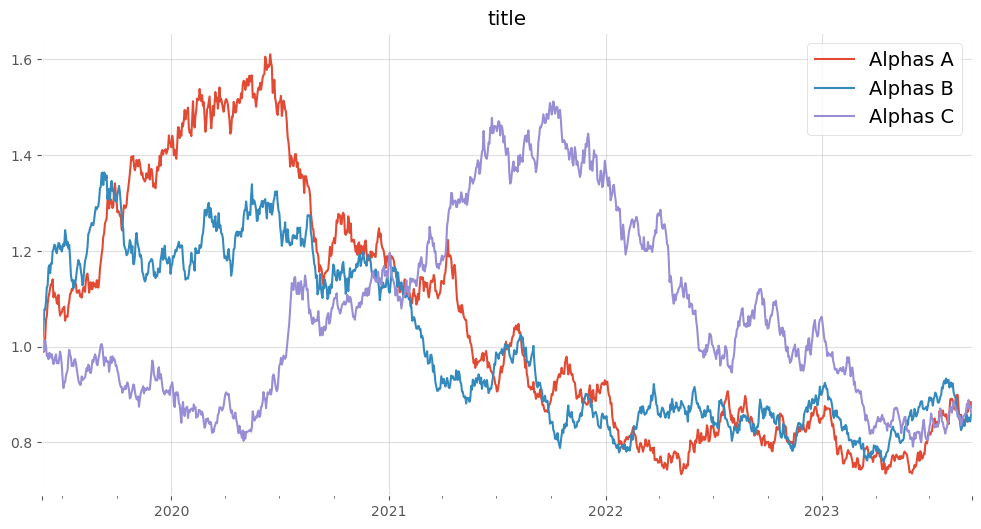

In [15]:
cum_passive_returns.plot(figsize=[12,6])
plt.title('title')

### <font color = blue> 👉 Question 3</font>. Cumulative Returns Over a 1120-Day Horizon:

- Extrapolate the cumulative returns for each Alpha over this period.
  
- When evaluating based on the Compound Annual Growth Rate (CAGR), how do these Alphas stack up against one another?

In [16]:
def compute_CAGR(cumulative_returns):
    """
    get_cagr Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        - The function drops missing values and uses the first and last available
      observations to compute CAGR as:
          (last_value / first_value) ** (365.0 / n_days) - 1
      where n_days is the integer number of days between the first and last index.
        - Uses 365-day convention for annualization. For trading-day conventions
        adjust the exponent accordingly.
        - If the series contains a single observation or zero-day span, the result
        may be ill-defined (division by zero or power of inf). Consider checking
        the index span before calling.
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (365.25 / n_of_days)
        - 1
    )
    return cagr

cagr_dct = {}
for ticker in cum_passive_returns.columns:
    cagr_dct[ticker] = compute_CAGR(cum_passive_returns[ticker])

In [17]:
cagr_dct

{'Alphas A': -0.03113935702955095,
 'Alphas B': -0.03286418953061776,
 'Alphas C': -0.031874284546903664}

### <font color = blue> 👉 Question 4</font>. Maximum Draw-down (MDD):

- Assess the Maximum Drawdown (MDD) for each model within this time frame.

- Based on this assessment, which Alpha appears best equipped to withstand market downturns?

In [18]:
dd_dct

{'Alphas A': (-0.544601997329252, 1183.0),
 'Alphas B': (-0.4437168929094025, 1463.0),
 'Alphas C': (-0.47675847269710636, 706.0)}

Alpha B is most resilient


### <font color = blue> 👉 Question 5</font>. Examining Drawdown Duration:

- Analyze the longest drawdown durations for each strategy.

- Which of the Alphas seems to have the quickest recovery mechanism following a significant drawdown?

Alpha C has the quickest recovery

### <font color = blue> 👉 Question 6</font>. Comprehensive Assessment of Strategy Performance:

- By synthesizing data from metrics such as the Sharpe ratio, cumulative returns trajectory, MDD, and drawdown duration, provide a well-rounded analysis of the three Alphas. 

- Rank and justify your recommendations based on your quantitative insights.

In [19]:
dd_df = pd.DataFrame(dd_dct).T
dd_df.columns = ['mdd', 'ldd']

In [20]:
dd_df

,mdd,ldd
Alphas A,-0.544602,1183.0
Alphas B,-0.443717,1463.0
Alphas C,-0.476758,706.0


In [21]:
sharpe_ratios_df = pd.Series(sharpe_ratios).to_frame()
sharpe_ratios_df.columns = ['sharpe']

In [22]:
sharpe_ratios_df

,sharpe
Alphas A,-0.155761
Alphas B,-0.165297
Alphas C,-0.160180


In [23]:
cagr_dct

{'Alphas A': -0.03113935702955095,
 'Alphas B': -0.03286418953061776,
 'Alphas C': -0.031874284546903664}

In [24]:
cagr_df = pd.Series(cagr_dct).to_frame()
cagr_df.columns = ['cagr']

In [25]:
cagr_df


,cagr
Alphas A,-0.031139
Alphas B,-0.032864
Alphas C,-0.031874


In [26]:
sharpe_ratios_df

,sharpe
Alphas A,-0.155761
Alphas B,-0.165297
Alphas C,-0.160180


In [27]:
dd_df.prod(axis=1) + sharpe_ratios_df[sharpe_ratios_df.columns[0]]

Alphas A   -644.419923
Alphas B   -649.323111
Alphas C   -336.751662
dtype: float64

### <font color = blue> 👉 Question 7</font>. Reflecting on the Sharpe Ratio:

- Given the observed disparities in cumulative returns and MDD among the Alphas, even with similar Sharpe ratios, evaluate the effectiveness of relying solely on the Sharpe ratio.

- Can you propose additional or refined metrics to differentiate between Alphas with matching Sharpe values but varying performances in other critical areas?

Integrate drawdown and find average

## 👇 Questions 8 to 12 ask you to build, execute, and backtest a strategy based on one kind of momentum strategy called the `Moving Average Convergence Divergence` (MACD) crossover.

### <font color = blue> 👉 Question 8</font>. Let’s take a look at Apple (AAPL) as our security of interest, over the three-year period of 2015 through 2017.

#### Moving Average Convergence Divergence (`MACD`) is a lagging, trend-following momentum indicator reflecting the relationship between two moving averages of stock prices.

#### The strategy utilizes two indicators, the MACD and the MACD signal line:

- The MACD is defined as the `difference` between the `12`-day ***exponential*** moving average and the `26`-day exponential moving average.
- The MACD `signal line` is then defined as the `9`-day ***exponential*** moving average of the MACD.

### <font color = green> NOTE: The MACD crossover strategy is defined as:

- A `bullish` crossover arises when the MACD line turns `upward and crosses` beyond the MACD signal line.
- A `bearish` crossover arises when the MACD line turns `downward and crosses` under the MACD signal line.

### Visualize your buy and sell positions.

In [29]:
aapl =\
yf.download(
    'AAPL',
    start='2014-01-01',
    end='2018-01-01'
)['Close']

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_48211/2600519080.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  1 of 1 completed


In [31]:
def compute_MACD(
    df: pd.DataFrame,
    span: list[int, int, int]
    ) -> pd.DataFrame:
    """
    Compute MACD / get_macd and signal-line for AAPL prices and attach intermediate EWMAs.
    Assumes first col is ticker data

    Parameters
        df : pandas.DataFrame Time-indexed DataFrame containing a column named "AAPL" with price data.
        span : list[int, int, int] Three integers specifying spans for exponential moving averages:
    Returns:
        pandas.DataFrame
    Usage:
        compute_MACD(aapl, [12, 26, 9])
    """
    ticker = df.columns[0]
    df[f"_{span[0]}_ewma"] =\
    (
        df
        [df.columns[0]]
        .ewm(span = span[0]
            )
        .mean()
    )

    df[f"_{span[1]}_ewma"] =\
    (
        df
        [df.columns[0]]
        .ewm(span = span[1]
            )
        .mean()
    )

    df["macd"] =\
    (
        df
        .eval(
            f"`_{span[0]}_ewma` - `_{span[1]}_ewma`"
        )
    )

    df["macd_signal"] =\
    (
        df
        ["macd"]
        .ewm(span = span[2]
            )
        .mean()
    )
    return df

In [32]:
aapl = compute_MACD(aapl, [12, 26, 9])

In [35]:
aapl['positions'] =\
np.where(
    aapl['macd']>aapl['macd_signal'], 1, -1)

In [ ]:
aapl = aapl.loc['2015-01-01':'2018-01-01']

In [43]:
aapl['trade'] = aapl['positions'].diff()
if aapl.at[aapl.index[0], 'positions'] != 0:
    aapl.at[aapl.index[0], 'trade'] = aapl.at[aapl.index[0], 'positions']

In [37]:

aapl['passive_returns'] = \
(
    np.log(
        aapl[aapl.columns[0]] / 
            aapl[aapl.columns[0]].shift(1)
    )
).fillna(0)
aapl['strategy_returns'] = \
(
    aapl['passive_returns'] * aapl['positions'].shift(1).fillna(0)
)
aapl['cum_passive_returns'] = \
(
    aapl['passive_returns'].cumsum().apply(np.exp).fillna(1)
)
aapl['cum_strategy_returns'] = \
(
    aapl['strategy_returns'].cumsum().apply(np.exp).fillna(1)
)

In [44]:
# TODO get_plot lets-plot; basic 
from lets_plot import *
LetsPlot.setup_html()

aapl_melt = aapl.reset_index()
# aapl_melt = aapl_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(aapl_melt, aes(x='Date')) +
    geom_line(aes(y='AAPL'), color='grey', size=0.7) +
    # geom_line(aes(y='ema_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='AAPL'), data=aapl_melt[aapl_melt['trade']>0.0], color='green', size=3) +       # amend trade as required
    geom_point(aes(y='AAPL'), data=aapl_melt[aapl_melt['trade']<-0.0], color='orange', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


p

In [46]:
p =\
(
    ggplot(aapl_melt, aes(x='Date')) +
    geom_line(aes(y='macd'), color='grey', size=0.7) +
    geom_line(aes(y='macd_signal'), color='blue', size=0.7) +   # amend sma as required
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='macd'), data=aapl_melt[aapl_melt['trade']>0.0], color='green', size=3) +       # amend trade as required
    geom_point(aes(y='macd'), data=aapl_melt[aapl_melt['trade']<-0.0], color='orange', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


p

### <font color = blue> 👉 Question 9</font>. Let’s suppose that you started from a $100,000 capital base for the given security.

### Given a $5 fixed commission fee per trade, how much in cumulative returns could you have had as a result of the MACD crossover strategy?

In [48]:
initial_cap = 100_000
cap = initial_cap
cum_strategy_returns = pd.Series(index=aapl.index)

for idx, row in aapl.iterrows():
    cap *= np.exp(row['strategy_returns'])
    if row['trade'] !=0:
        cap -= 5
    cum_strategy_returns.loc[idx] = cap

print(f"Final capital ${cap:,.0f}")

Final capital $207,426


### <font color = blue> 👉 Question 10</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

In [38]:
cum_strategy_returns

Date
2015-01-02     99995.000000
2015-01-05    102893.675439
2015-01-06    102884.004139
2015-01-07    101461.292826
2015-01-08     97707.160729
                  ...      
2017-12-22    211158.378321
2017-12-26    205796.288542
2017-12-27    205760.090349
2017-12-28    205182.821878
2017-12-29    207425.867971
Length: 755, dtype: float64

In [39]:
"""
 TODO get_drawdown_top max drawdown and duration table
"""
aapl['daily_drawdown'] = cum_strategy_returns / cum_strategy_returns.cummax() - 1
# take date column out and cumsum for periods
dd_reset = aapl.reset_index()
dd_reset['period'] = (dd_reset['daily_drawdown'] == 0).cumsum()
# find nodes with 0 value i.e. highpoints
dd_nonzero = dd_reset[dd_reset['daily_drawdown'] != 0]
# aggregate by period
period_stats = dd_nonzero.groupby('period').agg(
    start_date = ('Date', 'min'),
    end_date = ('Date', 'max'),
    avg_dd = ('daily_drawdown', 'mean'),
    max_dd = ('daily_drawdown', 'min'),
    duration=('daily_drawdown', 'count')
).sort_values(by='avg_dd',ascending=True)


## printing drawdowns
for _, row in period_stats.iterrows():
    print(f"The drawdown period: Nett drawdown {row['max_dd']:.2%} | Duration {row['duration']:.0f} Days")


The drawdown period: Nett drawdown -17.65% | Duration 207 Days
The drawdown period: Nett drawdown -17.41% | Duration 187 Days
The drawdown period: Nett drawdown -12.54% | Duration 41 Days
The drawdown period: Nett drawdown -6.70% | Duration 27 Days
The drawdown period: Nett drawdown -8.92% | Duration 35 Days
The drawdown period: Nett drawdown -7.13% | Duration 16 Days
The drawdown period: Nett drawdown -8.44% | Duration 11 Days
The drawdown period: Nett drawdown -4.83% | Duration 8 Days
The drawdown period: Nett drawdown -5.14% | Duration 8 Days
The drawdown period: Nett drawdown -3.08% | Duration 4 Days
The drawdown period: Nett drawdown -4.02% | Duration 13 Days
The drawdown period: Nett drawdown -3.11% | Duration 15 Days
The drawdown period: Nett drawdown -2.80% | Duration 7 Days
The drawdown period: Nett drawdown -3.41% | Duration 10 Days
The drawdown period: Nett drawdown -3.29% | Duration 4 Days
The drawdown period: Nett drawdown -3.19% | Duration 3 Days
The drawdown period: Nett

In [44]:
for i, row in enumerate(period_stats.itertuples(), start=1):
    ordinal = f"{i}{'tsnrhtdd'[i%5*(i%100^15>4>i%10)::4]}"
    print(f"The {ordinal} worst drawdown period : Net drawdown {row.max_dd:.2f}% | Duration {row.duration} Days\n")

The 1st worst drawdown period : Net drawdown -0.18% | Duration 207 Days

The 2nd worst drawdown period : Net drawdown -0.17% | Duration 187 Days

The 3rd worst drawdown period : Net drawdown -0.13% | Duration 41 Days

The 4th worst drawdown period : Net drawdown -0.07% | Duration 27 Days

The 5th worst drawdown period : Net drawdown -0.09% | Duration 35 Days

The 6th worst drawdown period : Net drawdown -0.07% | Duration 16 Days

The 7th worst drawdown period : Net drawdown -0.08% | Duration 11 Days

The 8th worst drawdown period : Net drawdown -0.05% | Duration 8 Days

The 9th worst drawdown period : Net drawdown -0.05% | Duration 8 Days

The 10th worst drawdown period : Net drawdown -0.03% | Duration 4 Days

The 11th worst drawdown period : Net drawdown -0.04% | Duration 13 Days

The 12th worst drawdown period : Net drawdown -0.03% | Duration 15 Days

The 13th worst drawdown period : Net drawdown -0.03% | Duration 7 Days

The 14th worst drawdown period : Net drawdown -0.03% | Duratio

### <font color = red> Answer 10 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

### <font color = blue> 👉 Question 11</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

In [45]:
def compute_CAGR(cumulative_returns):
    """
    get_cagr Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        - The function drops missing values and uses the first and last available
      observations to compute CAGR as:
          (last_value / first_value) ** (365.0 / n_days) - 1
      where n_days is the integer number of days between the first and last index.
        - Uses 365-day convention for annualization. For trading-day conventions
        adjust the exponent accordingly.
        - If the series contains a single observation or zero-day span, the result
        may be ill-defined (division by zero or power of inf). Consider checking
        the index span before calling.
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (365.25 / n_of_days)
        - 1
    )
    return cagr

In [46]:
splits = [
            '2015-01-01',
            '2016-01-01',
            '2017-01-01',
            '2018-01-01',
]
dct = {}
for idx, year in enumerate([2015, 2016, 2017]):
    dct[year] = aapl.loc[splits[idx]: splits[idx+1]]



### <font color = red> Answer 11 </font>

    Below average year(s) : ____________ 
    
    Above average year(s) : ____________ 
     

In [50]:
# ABove and below average years
ar_dct = {}
for year, df in dct.items():
    cum_rets = df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    ar_dct[year] = cum_rets.iloc[-1] - 1

avg = (np.mean(list(ar_dct.values())))
above = [k for k, v in ar_dct.items() if v > avg]
below = [k for k, v in ar_dct.items() if v < avg]

f"    Below average year(s) : {below}. Above average year(s) : {above}" 

'    Below average year(s) : [2015]. Above average year(s) : [2016, 2017]'

###  <font color = blue> 👉 Question 12. </font> What's the annualized Sharpe ratio of the current investment strategy?

In [52]:
def compute_sharpe_ratio(daily_returns):
    """
    get_sharpe Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std(ddof = 1)

sharpe = compute_sharpe_ratio(aapl['strategy_returns'])

### <font color = red> Answer 12 </font>
    
    Sharpe ratio: __________
    

In [54]:
f"Sharpe ratio: {sharpe:.5f}"

'Sharpe ratio: 1.06884'

use a metric to find the area of drawdown and average it. Use that to discount sharpe

### <font color="green">"💯 Thank you for putting your efforts into the exercise problem sets 😊"</font>